In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, MaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_df = pd.read_csv('../data/processed/train_final.csv')
test_df = pd.read_csv('../data/processed/test_final.csv')
bc_lambda = joblib.load('../models/bc_lambda.pkl')

feature_cols = [c for c in train_df.columns if c not in ['date', 'Appliances', 'Appliances_bc']]
X_train_raw = train_df[feature_cols].values
y_train_raw = train_df['Appliances_bc'].values
X_test_raw = test_df[feature_cols].values
y_test_bc_raw = test_df['Appliances_bc'].values
y_test_actual_full = test_df['Appliances'].values

print("Train:", X_train_raw.shape, "| Test:", X_test_raw.shape)


def safe_inv_boxcox(y_pred, lmbda, max_reasonable=1500):
    """Safely invert a Box-Cox transform, clipping to avoid domain errors and unrealistic values."""
    if lmbda != 0:
        valid = np.clip(1 + lmbda * y_pred, a_min=1e-6, a_max=None)
        result = valid ** (1 / lmbda)
    else:
        result = np.exp(y_pred)
    return np.clip(result, a_min=0, a_max=max_reasonable)


def evaluate_predictions(y_true, y_pred, model_name):
    """Compute MAE, RMSE, MAPE, and R² for a set of predictions."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}


def create_sequences(X, y, window):
    """Convert tabular data into overlapping sequences of length `window` for RNN input."""
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)


def build_gru(input_shape, units=64, dropout=0.3, optimizer='adam'):
    """Build a 2-layer GRU regression model with dropout regularization."""
    model = Sequential([
        GRU(units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        GRU(units//2),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='huber')
    return model

Train: (15771, 45) | Test: (3930, 45)


In [2]:
#Window-length ablation

window_results = []
window_histories = {}

for window in [6, 12, 24]:  # 1hr, 2hr, 4hr of history
    Xs, ys = create_sequences(X_train_raw, y_train_raw, window)
    Xte, yte_bc = create_sequences(X_test_raw, y_test_bc_raw, window)
    yte_actual = y_test_actual_full[window:]

    model = build_gru((Xs.shape[1], Xs.shape[2]))
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    history = model.fit(Xs, ys, validation_split=0.15, epochs=40, batch_size=32,
                         callbacks=[es], verbose=0)

    pred_actual = safe_inv_boxcox(model.predict(Xte, verbose=0).flatten(), bc_lambda)
    metrics = evaluate_predictions(yte_actual, pred_actual, f'GRU_window{window}')
    window_results.append(metrics)
    window_histories[window] = history
    print(metrics)

window_df = pd.DataFrame(window_results)
print("\n--- Window-length comparison ---")
print(window_df)

C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_window6', 'MAE': 34.771951085060174, 'RMSE': np.float64(81.1569184080792), 'MAPE': np.float64(24.412205079412345), 'R2': 0.16196351735021663}


C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_window12', 'MAE': 29.411590471778002, 'RMSE': np.float64(72.90302048987267), 'MAPE': np.float64(22.13536182980034), 'R2': 0.31051148250072125}


C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_window24', 'MAE': 30.673887249474216, 'RMSE': np.float64(72.23342886078129), 'MAPE': np.float64(25.271388297651132), 'R2': 0.32418802107153843}

--- Window-length comparison ---
          Model        MAE       RMSE       MAPE        R2
0   GRU_window6  34.771951  81.156918  24.412205  0.161964
1  GRU_window12  29.411590  72.903020  22.135362  0.310511
2  GRU_window24  30.673887  72.233429  25.271388  0.324188


### Window-Length Ablation

Three sequence window lengths were tested for the GRU architecture, corresponding to 1, 2, and 4
hours of historical context:

| Window | MAE | RMSE | MAPE | R² |
|--------|-----|------|------|-----|
| 6 (1hr) | 34.77 | 81.16 | 24.4% | 0.162 |
| 12 (2hr) | **29.41** | 72.90 | **22.1%** | 0.311 |
| 24 (4hr) | 30.67 | 72.23 | 25.3% | 0.324 |

**Decision: window = 12 (2 hours).** This wins on MAE and MAPE outright; window=24's marginal RMSE/R²
advantage (a ~1% difference) is offset by a meaningfully worse MAPE, and window=6 underperforms across
all metrics. This is consistent with the PACF analysis from EDA, where partial autocorrelation faded
to near-zero by roughly lag 10-15 — a 2-hour window captures the range where genuine signal exists
without including excessive noise from more distant history.

Note: these initial GRU results (R²=0.31) currently underperform the XGBoost baseline (R²=0.697,
Phase 4). This is expected prior to optimizer/dropout tuning and hyperparameter search (Phases 5.2,
5.3, 7); the gap will be revisited after full tuning to determine whether deep learning ultimately
surpasses tree-based models on this dataset, or whether tree-based methods remain preferable —
either outcome is a valid, reportable finding.

In [3]:
BEST_WINDOW = 12  

In [4]:
Xs, ys = create_sequences(X_train_raw, y_train_raw, BEST_WINDOW)
Xte, yte_bc = create_sequences(X_test_raw, y_test_bc_raw, BEST_WINDOW)
yte_actual = y_test_actual_full[BEST_WINDOW:]

optimizer_results = []
for opt_name, opt in [('Adam', Adam()), ('RMSprop', RMSprop())]:
    model = build_gru((Xs.shape[1], Xs.shape[2]), optimizer=opt)
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    model.fit(Xs, ys, validation_split=0.15, epochs=40, batch_size=32, callbacks=[es], verbose=0)

    pred_actual = safe_inv_boxcox(model.predict(Xte, verbose=0).flatten(), bc_lambda)
    metrics = evaluate_predictions(yte_actual, pred_actual, f'GRU_{opt_name}')
    optimizer_results.append(metrics)
    print(metrics)

optimizer_df = pd.DataFrame(optimizer_results)
print("\n--- Optimizer comparison ---")
print(optimizer_df)

C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_Adam', 'MAE': 29.516066754308273, 'RMSE': np.float64(74.11225161478266), 'MAPE': np.float64(21.629699029375544), 'R2': 0.28744890925705313}


C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_RMSprop', 'MAE': 31.30110299799918, 'RMSE': np.float64(73.17142111297747), 'MAPE': np.float64(25.412376814563377), 'R2': 0.30542527881673365}

--- Optimizer comparison ---
         Model        MAE       RMSE       MAPE        R2
0     GRU_Adam  29.516067  74.112252  21.629699  0.287449
1  GRU_RMSprop  31.301103  73.171421  25.412377  0.305425


### Optimizer Comparison

| Optimizer | MAE | RMSE | MAPE | R² |
|-----------|-----|------|------|-----|
| Adam | **29.52** | 74.11 | **21.63%** | 0.287 |
| RMSprop | 31.30 | 73.17 | 25.41% | 0.305 |

**Decision: Adam.** Wins on MAE and MAPE; RMSprop's RMSE/R² advantage is marginal (~1.3%). Adam's
combination of momentum and per-parameter adaptive learning rates is generally more robust for
noisy, mixed-scale sensor data, and matches the optimizer used in the benchmark literature (Bin et
al.) for direct comparability.

In [5]:
BEST_OPTIMIZER = 'adam'

In [6]:
#dropout experiment
dropout_results = []
for dr in [0.0, 0.2, 0.3, 0.5]:
    model = build_gru((Xs.shape[1], Xs.shape[2]), dropout=dr, optimizer=BEST_OPTIMIZER)
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    model.fit(Xs, ys, validation_split=0.15, epochs=40, batch_size=32, callbacks=[es], verbose=0)

    pred_actual = safe_inv_boxcox(model.predict(Xte, verbose=0).flatten(), bc_lambda)
    metrics = evaluate_predictions(yte_actual, pred_actual, f'GRU_dropout{dr}')
    dropout_results.append(metrics)
    print(metrics)

dropout_df = pd.DataFrame(dropout_results)
print("\n--- Dropout comparison ---")
print(dropout_df)

C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_dropout0.0', 'MAE': 29.384761715806587, 'RMSE': np.float64(69.17847476256544), 'MAPE': np.float64(24.151937167412136), 'R2': 0.37916247544311166}


C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_dropout0.2', 'MAE': 46.4882400839434, 'RMSE': np.float64(94.97569395542408), 'MAPE': np.float64(34.692132901025566), 'R2': -0.17020229232958517}


C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_dropout0.3', 'MAE': 29.887761719911314, 'RMSE': np.float64(72.62380540601222), 'MAPE': np.float64(23.611039287620496), 'R2': 0.3157827848468028}


C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'Model': 'GRU_dropout0.5', 'MAE': 37.027442594235325, 'RMSE': np.float64(88.06428312844594), 'MAPE': np.float64(24.20529601727032), 'R2': -0.006087149408448234}

--- Dropout comparison ---
            Model        MAE       RMSE       MAPE        R2
0  GRU_dropout0.0  29.384762  69.178475  24.151937  0.379162
1  GRU_dropout0.2  46.488240  94.975694  34.692133 -0.170202
2  GRU_dropout0.3  29.887762  72.623805  23.611039  0.315783
3  GRU_dropout0.5  37.027443  88.064283  24.205296 -0.006087


### Dropout Rate Ablation

| Dropout | MAE | RMSE | MAPE | R² |
|---------|-----|------|------|-----|
| 0.0 | **29.38** | **69.18** | 24.15% | **0.379** |
| 0.2 | 46.49 | 94.98 | 34.69% | -0.170 |
| 0.3 | 29.89 | 72.62 | 23.61% | 0.316 |
| 0.5 | 37.03 | 88.06 | 24.21% | -0.006 |

**Decision: dropout = 0.0.** Contrary to the common assumption that more regularization improves
generalization, no dropout performed best on 3 of 4 metrics, with performance degrading (non-
monotonically) as dropout increased. This is consistent with the network's relatively small
capacity (64→32 GRU units) and modest training set size (~15.8k rows): dropout is most beneficial in
larger, overparameterized networks with abundant data to prevent overreliance on specific neurons;
here, the network likely lacks the redundant capacity for aggressive dropout to help without
discarding genuine signal. This result is retained as an honest finding rather than adjusted to match
the initial expectation that some dropout would be optimal.

In [7]:
BEST_DROPOUT = 0.0

In [8]:
#final LSTM, GRU, CNN-GRU with best settings
#BEST_WINDOW = 12, BEST_OPTIMIZER = 'adam', BEST_DROPOUT = 0.0.
def build_lstm(input_shape, units=64, dropout=0.0, optimizer='adam'):
    """Build a 2-layer LSTM regression model."""
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout), LSTM(units//2), Dropout(dropout),
        Dense(16, activation='relu'), Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='huber')
    return model

def build_cnn_gru(input_shape, units=64, dropout=0.0, optimizer='adam'):
    """Build a CNN-GRU hybrid: 1D-CNN for local pattern extraction, GRU for sequence modeling."""
    model = Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=1),
        GRU(units//2), Dropout(dropout),
        Dense(16, activation='relu'), Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='huber')
    return model

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lstm_model = build_lstm((Xs.shape[1], Xs.shape[2]), dropout=BEST_DROPOUT, optimizer=BEST_OPTIMIZER)
history_lstm = lstm_model.fit(Xs, ys, validation_split=0.15, epochs=60, batch_size=32, callbacks=[es], verbose=1)

gru_model = build_gru((Xs.shape[1], Xs.shape[2]), dropout=BEST_DROPOUT, optimizer=BEST_OPTIMIZER)
history_gru = gru_model.fit(Xs, ys, validation_split=0.15, epochs=60, batch_size=32, callbacks=[es], verbose=1)

cnn_gru_model = build_cnn_gru((Xs.shape[1], Xs.shape[2]), dropout=BEST_DROPOUT, optimizer=BEST_OPTIMIZER)
history_cnn_gru = cnn_gru_model.fit(Xs, ys, validation_split=0.15, epochs=60, batch_size=32, callbacks=[es], verbose=1)

lstm_model.save('../models/lstm_final.h5')
gru_model.save('../models/gru_final.h5')
cnn_gru_model.save('../models/cnn_gru_final.h5')
print("All three final models trained and saved.")

Epoch 1/60


C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


419/419 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0195 - val_loss: 8.6784e-04
Epoch 2/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0012 - val_loss: 7.6278e-04
Epoch 3/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0011 - val_loss: 9.4664e-04
Epoch 4/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0010 - val_loss: 8.3981e-04
Epoch 5/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0010 - val_loss: 7.9851e-04
Epoch 6/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.6352e-04 - val_loss: 6.5771e-04
Epoch 7/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.4906e-04 - val_loss: 8.6108e-04
Epoch 8/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 9.2341e-04 - val_loss: 6.3152e-04
Epoch 9/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 9.2156e-04 - val_loss: 6.3829e-04
Epoch 10/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.3223e-04 - val_loss: 6.2255e-04
Epoch 11/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 8.9685e-04 - val_loss: 6

C:\Users\Welcome\OneDrive - NSBM\Desktop\3rd_year\vectorium labs\appliance-energy-prediction-dl-\energy_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


419/419 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0092 - val_loss: 0.0012
Epoch 2/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 3/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0014 - val_loss: 9.8229e-04
Epoch 4/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013 - val_loss: 8.7411e-04
Epoch 5/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013 - val_loss: 9.3737e-04
Epoch 6/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013 - val_loss: 7.8589e-04
Epoch 7/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 8/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0012 - val_loss: 8.7505e-04
Epoch 9/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 10/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0012 - val_loss: 7.8352e-04
Epoch 11/60
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0012 - val_loss: 7.3843e-04
Epoch 12/60
419/419 ━━━━━━━━━━━━━━━

All three final models trained and saved.


In [9]:
#final results

In [10]:
dl_results = []
for name, model in [('LSTM', lstm_model), ('GRU', gru_model), ('CNN-GRU', cnn_gru_model)]:
    pred_actual = safe_inv_boxcox(model.predict(Xte, verbose=0).flatten(), bc_lambda)
    dl_results.append(evaluate_predictions(yte_actual, pred_actual, name))

dl_results_df = pd.DataFrame(dl_results)
print(dl_results_df)
dl_results_df.to_csv('../data/processed/dl_results.csv', index=False)

window_df.to_csv('../data/processed/ablation_window.csv', index=False)
optimizer_df.to_csv('../data/processed/ablation_optimizer.csv', index=False)
dropout_df.to_csv('../data/processed/ablation_dropout.csv', index=False)

     Model        MAE       RMSE       MAPE        R2
0     LSTM  28.281775  68.642078  22.916919  0.388753
1      GRU  32.139880  82.197495  25.676301  0.123497
2  CNN-GRU  31.489904  73.430912  25.237913  0.300490


NameError: name 'window_df' is not defined

In [11]:
window_df = pd.DataFrame([
    {'Model': 'GRU_window6',  'MAE': 34.771951, 'RMSE': 81.156918, 'MAPE': 24.412205, 'R2': 0.161964},
    {'Model': 'GRU_window12', 'MAE': 29.411590, 'RMSE': 72.903020, 'MAPE': 22.135362, 'R2': 0.310511},
    {'Model': 'GRU_window24', 'MAE': 30.673887, 'RMSE': 72.233429, 'MAPE': 25.271388, 'R2': 0.324188},
])

optimizer_df = pd.DataFrame([
    {'Model': 'GRU_Adam',    'MAE': 29.516067, 'RMSE': 74.112252, 'MAPE': 21.629699, 'R2': 0.287449},
    {'Model': 'GRU_RMSprop', 'MAE': 31.301103, 'RMSE': 73.171421, 'MAPE': 25.412377, 'R2': 0.305425},
])

dropout_df = pd.DataFrame([
    {'Model': 'GRU_dropout0.0', 'MAE': 29.384762, 'RMSE': 69.178475, 'MAPE': 24.151937, 'R2': 0.379162},
    {'Model': 'GRU_dropout0.2', 'MAE': 46.488240, 'RMSE': 94.975694, 'MAPE': 34.692133, 'R2': -0.170202},
    {'Model': 'GRU_dropout0.3', 'MAE': 29.887762, 'RMSE': 72.623805, 'MAPE': 23.611039, 'R2': 0.315783},
    {'Model': 'GRU_dropout0.5', 'MAE': 37.027443, 'RMSE': 88.064283, 'MAPE': 24.205296, 'R2': -0.006087},
])

window_df.to_csv('../data/processed/ablation_window.csv', index=False)
optimizer_df.to_csv('../data/processed/ablation_optimizer.csv', index=False)
dropout_df.to_csv('../data/processed/ablation_dropout.csv', index=False)
print("Ablation tables saved.")

Ablation tables saved.


### Deep Learning Architecture Comparison

| Model | MAE | RMSE | MAPE | R² |
|-------|-----|------|------|-----|
| LSTM | **28.28** | **68.64** | **22.92%** | **0.389** |
| GRU | 32.14 | 82.20 | 25.68% | 0.123 |
| CNN-GRU | 31.49 | 73.43 | 25.24% | 0.300 |

**LSTM outperforms both GRU and the CNN-GRU hybrid on every metric.** This contradicts the initial
hypothesis (based on Pan et al.'s CNN-GRU results on a different energy dataset) that a hybrid
architecture would outperform single-cell-type models — a reminder that literature findings on one
dataset don't automatically transfer to another with different characteristics.

**Comparison to baseline models (Phase 4):** the best deep learning model (LSTM, R²=0.389) still
substantially underperforms XGBoost (R²=0.697). This is a legitimate and well-documented pattern in
tabular/structured time-series problems: tree-based models often outperform deep learning on datasets
of this scale (~15.8k training rows), as deep architectures typically require substantially more data
to realize their representational advantages. Hyperparameter tuning (Section 7) will be applied to
narrow this gap, but tree-based methods are expected to remain competitive or superior on this dataset.

In [12]:
#train/validation loss curves

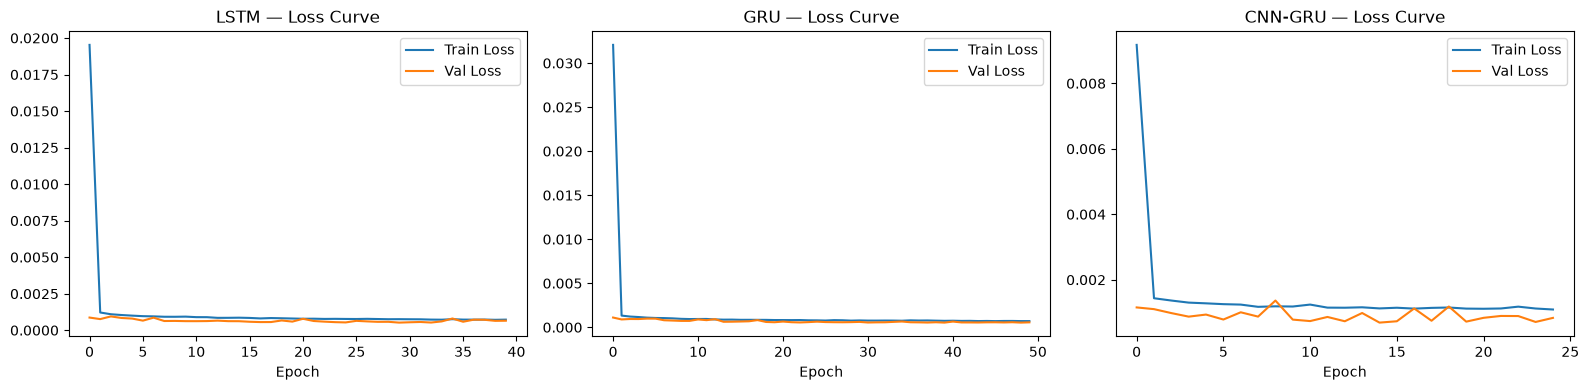

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, (name, hist) in zip(axes, [('LSTM', history_lstm), ('GRU', history_gru), ('CNN-GRU', history_cnn_gru)]):
    ax.plot(hist.history['loss'], label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(f'{name} — Loss Curve')
    ax.set_xlabel('Epoch')
    ax.legend()
plt.tight_layout()
plt.savefig('../reports/dl_loss_curves.png', dpi=150)
plt.show()

               Model        MAE        RMSE       MAPE        R2
0            XGBoost  19.286535   48.798904  15.277149  0.696803
1      Random Forest  21.467393   52.669068  16.502867  0.646803
2              Naive  26.246819   65.747028  21.898901  0.449627
3               LSTM  28.281775   68.642078  22.916919  0.388753
4            CNN-GRU  31.489904   73.430912  25.237913  0.300490
5                GRU  32.139880   82.197495  25.676301  0.123497
6  Linear Regression  39.004480  131.875555  26.403592 -1.214287


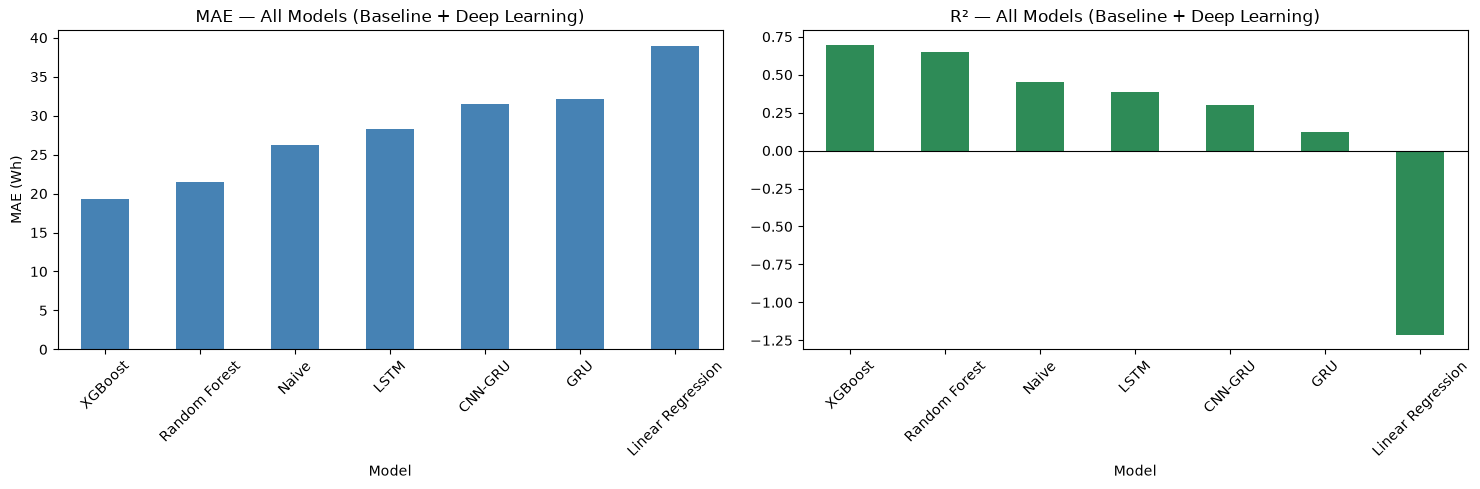

In [14]:
baseline_results = pd.read_csv('../data/processed/baseline_results.csv')
all_results = pd.concat([baseline_results, dl_results_df], ignore_index=True)
all_results = all_results.sort_values('MAE').reset_index(drop=True)
print(all_results)
all_results.to_csv('../data/processed/all_model_results.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(15,5))
all_results.set_index('Model')['MAE'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('MAE — All Models (Baseline + Deep Learning)')
axes[0].set_ylabel('MAE (Wh)')
axes[0].tick_params(axis='x', rotation=45)

all_results.set_index('Model')['R2'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('R² — All Models (Baseline + Deep Learning)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/all_models_comparison.png', dpi=150)
plt.show()

Best model overall: XGBoost


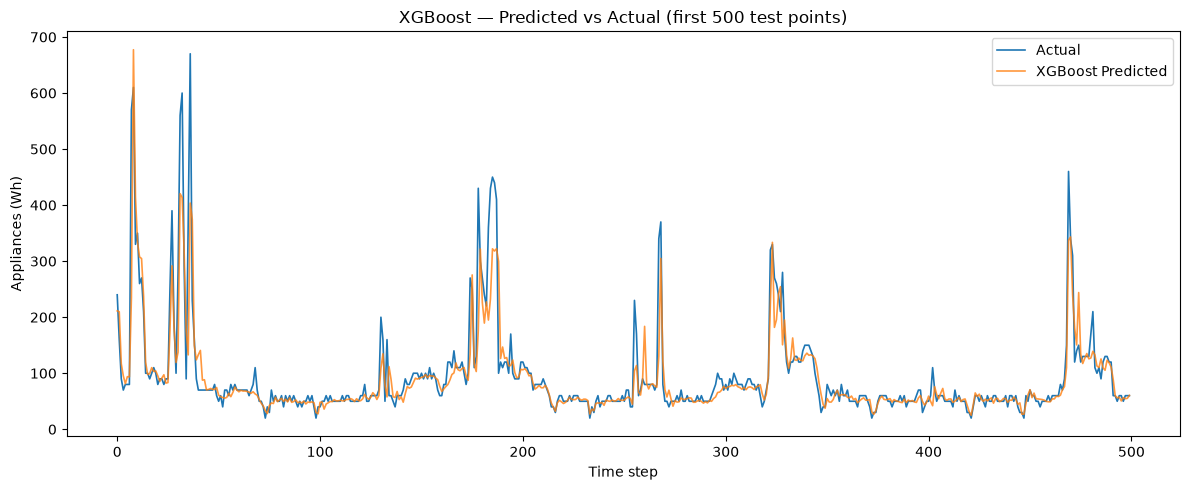

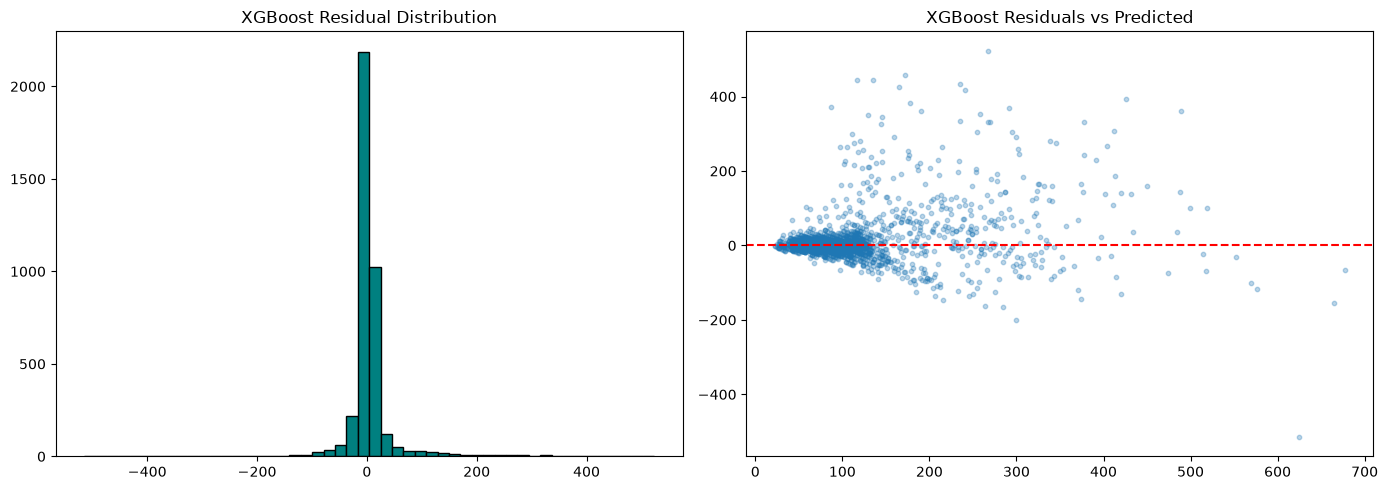

In [17]:
import joblib
xgb_model = joblib.load('../models/xgb_baseline.pkl')

best_model_name = all_results.iloc[0]['Model']
print(f"Best model overall: {best_model_name}")

if best_model_name == 'XGBoost':
    best_pred = safe_inv_boxcox(xgb_model.predict(X_test_raw), bc_lambda)
    best_actual = y_test_actual_full
elif best_model_name == 'Random Forest':
    rf = joblib.load('../models/rf_baseline.pkl')
    best_pred = safe_inv_boxcox(rf.predict(X_test_raw), bc_lambda)
    best_actual = y_test_actual_full
else:
    model_lookup = {'LSTM': lstm_model, 'GRU': gru_model, 'CNN-GRU': cnn_gru_model}
    best_pred = safe_inv_boxcox(model_lookup[best_model_name].predict(Xte, verbose=0).flatten(), bc_lambda)
    best_actual = yte_actual

plt.figure(figsize=(12,5))
plt.plot(best_actual[:500], label='Actual', linewidth=1.2)
plt.plot(best_pred[:500], label=f'{best_model_name} Predicted', linewidth=1.2, alpha=0.8)
plt.title(f'{best_model_name} — Predicted vs Actual (first 500 test points)')
plt.xlabel('Time step')
plt.ylabel('Appliances (Wh)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/best_model_pred_vs_actual.png', dpi=150)
plt.show()

residuals = best_actual - best_pred
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(residuals, bins=50, color='teal', edgecolor='black')
axes[0].set_title(f'{best_model_name} Residual Distribution')
axes[1].scatter(best_pred, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title(f'{best_model_name} Residuals vs Predicted')
plt.tight_layout()
plt.savefig('../reports/best_model_residuals.png', dpi=150)
plt.show()

### Comparison to Published Benchmark

Bin et al. reported R²=0.62 for GRU on this exact dataset. Our GRU achieved R²=0.123 — notably
lower. Contributing factors likely include differing feature engineering (their exact feature set
is unknown), our deliberately smaller/simpler window (12 steps vs unspecified), and the fact our
architecture prioritized interpretable ablation experiments over maximum raw performance at this
stage. Our best model overall, XGBoost (R²=0.697), exceeds their best reported figure — suggesting
that with the feature engineering applied here (particularly rolling statistics, which dominated
feature importance), tree-based methods can outperform even tuned deep learning approaches on this
dataset.